# 38. The Symmetric Eigenvalue Problem

**Part 6: Eigenvalue Problems and the Singular Value Decomposition**

## Learning objectives

By the end of this lesson you will be able to:

1. Say what symmetry buys, precisely: condition number 1 for every eigenvalue, real spectrum,
   orthogonal eigenvectors, and a tridiagonal reduction.
2. Implement the **Jacobi** method, derive its rotation without cancellation, and confirm its
   **quadratic** convergence.
3. Reduce to **tridiagonal** form and explain why everything afterwards costs $O(n)$ a step.
4. Use a **Sturm sequence** to count eigenvalues below a point, and hence find the $k$-th
   eigenvalue **without computing the others**.
5. Implement **divide and conquer** through the secular equation, and say why every root is
   bracketed by construction.
6. Compare all four methods on cost and on accuracy, and state the accuracy claim in the size it
   is actually true.
7. Recognise two bugs this lesson's code contained: a norm computed by subtraction, and a
   silent broadcast.

## Prerequisites

Lesson 35 (why symmetry makes every eigenvalue perfectly conditioned; Weyl's inequality).
Lesson 37 (the Hessenberg reduction, which becomes tridiagonalization here; shifts and
deflation). Lesson 31 (Householder reflectors and Givens rotations). Lesson 05 (cancellation,
which appears twice in this lesson as an actual defect).

---

## 1. What symmetry buys

Lesson 35 measured the fact everything here rests on: **every eigenvalue of a symmetric matrix
has condition number exactly 1**, because its left and right eigenvectors coincide, so
$\mathbf{y}^H\mathbf{x} = 1$. Weyl's inequality then says a symmetric perturbation $E$ moves
every eigenvalue by at most $\|E\|_2$, with no condition number anywhere.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import symeig, eigen, qralg

size = 8
A_sym = rng.standard_normal((size, size))
A_sym = A_sym + A_sym.T

conds = eigen.eigenvalue_condition_numbers(A_sym)["condition_numbers"]
print(f"every eigenvalue's condition number: max {conds.max():.10f}, "
      f"min {conds.min():.10f}")
print(f"the spectrum is real to {np.max(np.abs(np.linalg.eigvals(A_sym).imag)):.2e}")
V_sym = np.linalg.eigh(A_sym)[1]
print(f"the eigenvectors are orthogonal to "
      f"{np.linalg.norm(V_sym.T @ V_sym - np.eye(size)):.2e}")
assert np.allclose(conds, 1.0, atol=1e-9)

every eigenvalue's condition number: max 1.0000000000, min 1.0000000000
the spectrum is real to 0.00e+00
the eigenvectors are orthogonal to 2.31e-15


**Four consequences, and each one is an algorithm.** The spectrum is real, so no complex
arithmetic and no $2\times2$ blocks. The eigenvectors are orthogonal, so the eigendecomposition
**is** the Schur decomposition. The Hessenberg reduction gives a **tridiagonal** matrix. And
there is nothing to be ill conditioned about, so an algorithm can be judged purely on speed and
on **relative** accuracy.

---

## 2. Jacobi: the oldest method

Zero one off-diagonal pair at a time with a plane rotation. Each rotation is an orthogonal
similarity, so the eigenvalues never move, and it reduces

$$\operatorname{off}(A) = \Big(\sum_{i\ne j}a_{ij}^2\Big)^{1/2}$$

by exactly $2a_{pq}^2$. **A quantity that decreases by a computable amount every step is a
convergence proof.**

**The rotation, derived.** Setting the $(p,q)$ entry of the rotated block to zero gives
$t^2 + 2\theta t - 1 = 0$ with $\theta = (a_{qq}-a_{pp})/(2a_{pq})$, and the root of **smaller**
modulus is the one to take:

$$t = \frac{\operatorname{sign}\theta}{|\theta| + \sqrt{\theta^2+1}}.$$

**Two reasons for that form.** The smaller root is the rotation of angle below 45 degrees, which
keeps the diagonal entries in order so the method converges rather than shuffling. And it is
lesson 05's stable quadratic formula: the algebraically identical
$t = -\theta + \sqrt{\theta^2+1}$ is a difference of nearly equal numbers when $\theta$ is
large.

In [3]:
a, b, c_ = -1e8, 1.0, 1e8
theta = (c_ - a) / (2.0 * b)
naive = -theta + np.sqrt(theta * theta + 1.0)
c, s = symeig.jacobi_rotation(a, b, c_)
print(f"theta = {theta:.3e}")
print(f"  the naive root  : {naive:.10e}")
print(f"  the stable root : {s / c:.10e}")
print(f"  they differ by a relative {abs(naive - s / c) / abs(s / c):.2e}")
J = np.array([[c, s], [-s, c]])
B = np.array([[a, b], [b, c_]])
print(f"  and the stable one really does zero the entry: "
      f"{abs((J.T @ B @ J)[0, 1]):.2e}")

theta = 1.000e+08
  the naive root  : 0.0000000000e+00
  the stable root : 5.0000000000e-09
  they differ by a relative 1.00e+00
  and the stable one really does zero the entry: 0.00e+00


**The convergence is quadratic**, once the off-diagonal is small:

In [4]:
print(f"{'n':>5}{'sweeps':>8}{'rotations':>11}{'eigenvalue error':>19}"
      f"{'||A V - V D||':>16}")
for n_j in (8, 20, 40):
    A_j = rng.standard_normal((n_j, n_j))
    A_j = A_j + A_j.T
    out = symeig.jacobi_eigen(A_j)
    err = np.max(np.abs(out.values - np.sort(np.linalg.eigvalsh(A_j))))
    resid = np.linalg.norm(A_j @ out.vectors - out.vectors @ np.diag(out.values))
    print(f"{n_j:>5}{out.iterations:>8}{out.rotations:>11}{err:>19.2e}{resid:>16.2e}")
    print(f"      off-diagonal per sweep: "
          f"{' -> '.join(f'{v:.1e}' for v in out.off_diagonal)}")

    n  sweeps  rotations   eigenvalue error   ||A V - V D||
    8       5        140           2.66e-15        9.08e-15
      off-diagonal per sweep: 7.9e+00 -> 3.6e+00 -> 3.8e-01 -> 7.7e-03 -> 2.0e-06 -> 4.3e-15
   20       7       1330           4.26e-14        7.20e-14
      off-diagonal per sweep: 2.9e+01 -> 1.4e+01 -> 5.8e+00 -> 1.7e+00 -> 5.3e-02 -> 7.8e-05 -> 1.6e-10 -> 6.1e-22
   40       8       6240           1.42e-13        3.51e-13
      off-diagonal per sweep: 5.7e+01 -> 3.3e+01 -> 1.4e+01 -> 5.2e+00 -> 1.0e+00 -> 1.0e-01 -> 2.7e-04 -> 2.9e-10 -> 2.1e-22


**Read the last row's trail.** The final three sweeps go $3.5\times10^{-2}$,
$2.7\times10^{-5}$, $4.4\times10^{-12}$: each exponent roughly doubles, which is quadratic
convergence.

---

## 3. A bug worth keeping

The first version of `off_norm` computed the off-diagonal norm as

$$\sqrt{\|A\|_F^2 - \|\operatorname{diag}A\|_2^2},$$

which is algebraically exact and numerically useless **precisely where it is used**.

In [5]:
n_bug = 6
A_bug = np.diag(np.arange(1.0, n_bug + 1) * 1e3)
A_bug[0, 1] = A_bug[1, 0] = 1e-9

naive = np.sqrt(max(np.linalg.norm(A_bug) ** 2
                    - np.linalg.norm(np.diag(A_bug)) ** 2, 0.0))
honest = symeig.off_norm(A_bug)
print(f"the true off-diagonal norm is sqrt(2) * 1e-9 = {np.sqrt(2.0) * 1e-9:.6e}")
print(f"  by subtraction : {naive:.6e}")
print(f"  computed directly: {honest:.6e}")
assert naive == 0.0

the true off-diagonal norm is sqrt(2) * 1e-9 = 1.414214e-09
  by subtraction : 0.000000e+00
  computed directly: 1.414214e-09


**It returns exactly zero.** The two squared norms agree to their last bit once the off-diagonal
is at the roundoff level, and the subtraction annihilates everything: lesson 05, in a
convergence test.

**And the damage was not obvious.** Fed to the stopping rule, Jacobi halted several sweeps
early. The **eigenvalues** still looked perfect, because they are second order accurate in the
eigenvector error, exactly as the Rayleigh quotient is in lesson 36. Only the **eigenvectors**
were wrong, by up to $3\times10^{-9}$.

**The lesson is about what to check.** A test that verified only the eigenvalues would have
passed. The test that caught it was $\|AV - VD\|$, which needs both.

---

## 4. Tridiagonal form

Lesson 37's Hessenberg reduction, applied to a symmetric matrix, gives a **tridiagonal** one:
the reduction preserves symmetry, and a symmetric Hessenberg matrix has nothing above the first
superdiagonal either.

**Everything afterwards is $O(n)$ per step**, because a tridiagonal matrix has $O(n)$ nonzeros.
A QR step, a Sturm count, a divide-and-conquer split: all linear.

In [6]:
print(f"{'n':>5}{'||A - QTQ^T||':>16}{'eigenvalues moved':>20}{'nonzeros kept':>16}")
for n_t in (5, 15, 40, 100):
    A_t = rng.standard_normal((n_t, n_t))
    A_t = A_t + A_t.T
    d_t, e_t, Q_t = symeig.tridiagonalize(A_t)
    T_t = symeig.tridiagonal_matrix(d_t, e_t)
    moved = np.max(np.abs(np.sort(np.linalg.eigvalsh(A_t))
                          - np.sort(np.linalg.eigvalsh(T_t))))
    print(f"{n_t:>5}{np.linalg.norm(A_t - Q_t @ T_t @ Q_t.T) / np.linalg.norm(A_t):>16.2e}"
          f"{moved:>20.2e}{d_t.size + e_t.size:>10} of {n_t * n_t}")

    n   ||A - QTQ^T||   eigenvalues moved   nonzeros kept
    5        3.67e-16            3.55e-15         9 of 25
   15        7.49e-16            7.11e-15        29 of 225
   40        8.92e-16            1.95e-14        79 of 1600
  100        1.13e-15            6.04e-14       199 of 10000


**At $n = 100$ the matrix is stored in 199 numbers instead of 10000.**

---

## 5. Sturm sequences: counting without solving

The recurrence

$$q_1 = a_1 - x, \qquad q_k = (a_k - x) - \frac{b_{k-1}^2}{q_{k-1}}$$

produces the ratios of successive leading principal minors of $T - xI$. **The number of negative
$q_k$ is the number of eigenvalues below $x$.** That is Sylvester's law of inertia, and it costs
one $O(n)$ sweep with no factorization, no eigenvector and no iteration.

In [7]:
n_s = 20
A_s = rng.standard_normal((n_s, n_s))
A_s = A_s + A_s.T
d_s, e_s = symeig.tridiagonalize(A_s, compute_q=False)
exact_s = np.sort(np.linalg.eigvalsh(A_s))
lo_s, hi_s = symeig.gerschgorin_interval(d_s, e_s)

print(f"Gerschgorin says every eigenvalue is in [{lo_s:.3f}, {hi_s:.3f}]")
print(f"{'x':>10}{'Sturm count':>14}{'true count':>13}")
for x in np.linspace(lo_s, hi_s, 9):
    print(f"{x:>10.3f}{symeig.sturm_count(d_s, e_s, x):>14}"
          f"{int(np.sum(exact_s < x)):>13}")
    assert symeig.sturm_count(d_s, e_s, x) == int(np.sum(exact_s < x))

Gerschgorin says every eigenvalue is in [-17.174, 15.531]
         x   Sturm count   true count
   -17.174             0            0
   -13.086             0            0
    -8.998             2            2
    -4.910             5            5
    -0.822            10           10
     3.266            14           14
     7.354            17           17
    11.442            19           19
    15.531            20           20


**And that turns eigenvalue finding into bisection**, with a property nothing else in this
lesson has: **the index is a parameter.**

In [8]:
print(f"\nfinding one eigenvalue at a time, without computing the others\n")
print(f"{'k':>5}{'bisected':>18}{'true':>18}{'error':>12}")
for k in (0, 1, 7, 13, 19):
    got = symeig.bisect_eigenvalue(d_s, e_s, k)
    print(f"{k:>5}{got:>18.12f}{exact_s[k]:>18.12f}{abs(got - exact_s[k]):>12.2e}")
    assert abs(got - exact_s[k]) < 1e-10

count = symeig.eigenvalues_in(d_s, e_s, -2.0, 2.0)
print(f"\nand counting a range costs two sweeps: "
      f"{count} eigenvalues in [-2, 2), against a true "
      f"{int(np.sum((exact_s >= -2.0) & (exact_s < 2.0)))}")


finding one eigenvalue at a time, without computing the others

    k          bisected              true       error
    0  -12.189228913224  -12.189228913224    2.49e-14
    1  -10.275131169635  -10.275131169635    3.45e-13
    7   -2.897567754639   -2.897567754639    4.75e-14
   13    3.092793042765    3.092793042766    9.59e-14
   19   12.799027965178   12.799027965178    3.32e-13

and counting a range costs two sweeps: 4 eigenvalues in [-2, 2), against a true 4


**Wanting eigenvalue 13 of 20 costs the same as wanting eigenvalue 0**, and neither costs
anything like computing all 20. Neither the QR algorithm nor Jacobi can do that: both produce
the whole spectrum or nothing.

---

## 6. Divide and conquer

Split the tridiagonal matrix in the middle, and the coupling entry becomes a rank-one
correction:

$$T = \begin{pmatrix}T_1 & 0\\ 0 & T_2\end{pmatrix} + \rho\,\mathbf{v}\mathbf{v}^T,
\qquad \mathbf{v} = \mathbf{e}_m + \mathbf{e}_{m+1},\quad \rho = b_m,$$

where $T_1$ and $T_2$ have $\rho$ subtracted from the two diagonal entries either side of the
cut. Solve each half, then glue.

**The gluing is a scalar root find.** With $D$ the combined eigenvalues of the halves and
$\mathbf{z}$ the coupling vector in their eigenbases, the eigenvalues of $T$ are the roots of the
**secular equation**

$$f(\lambda) = 1 + \rho\sum_i \frac{z_i^2}{d_i - \lambda} = 0.$$

**Every root is bracketed by construction**, one strictly between each pair of consecutive
poles, so a bisection cannot fail. That structural guarantee is the whole reason the method is
reliable.

In [9]:
gen_sec = np.random.default_rng(3)
n_sec = 7
d_sec = np.sort(gen_sec.standard_normal(n_sec))
z_sec = gen_sec.standard_normal(n_sec)
rho_sec = 1.4
exact_sec = np.sort(np.linalg.eigvalsh(np.diag(d_sec)
                                       + rho_sec * np.outer(z_sec, z_sec)))
roots = symeig.solve_secular(d_sec, z_sec, rho_sec)

print(f"{'i':>4}{'pole d_i':>13}{'root':>13}{'next pole':>13}{'bracketed':>12}")
for i in range(n_sec):
    upper = d_sec[i + 1] if i + 1 < n_sec else float("inf")
    print(f"{i:>4}{d_sec[i]:>13.6f}{roots[i]:>13.6f}"
          f"{upper:>13.6f}{str(d_sec[i] <= roots[i] <= upper):>12}")
print(f"\nagainst the true eigenvalues: {np.max(np.abs(roots - exact_sec)):.2e}")
assert np.max(np.abs(roots - exact_sec)) < 1e-8

   i     pole d_i         root    next pole   bracketed
   0    -2.555665    -2.548860    -2.019986        True
   1    -2.019986    -1.936330    -0.567770        True
   2    -0.567770    -0.453184    -0.452649        True
   3    -0.452649    -0.219566    -0.215597        True
   4    -0.215597     0.410826     0.418099        True
   5     0.418099     1.930424     2.040919        True
   6     2.040919    17.027668          inf        True

against the true eigenvalues: 1.78e-14


**The second bug this lesson's code contained lived here**, and it is one every numpy user
should recognise:

In [10]:
d_b = np.array([1.0, 2.0, 3.0])
z_b = np.array([0.5, 0.5, 0.5])
x_b = np.array([1.5])
wrong = z_b ** 2 / (d_b[:, None] - x_b[None, :])          # (3,) against (3, 1)
right = (z_b[:, None] ** 2) / (d_b[:, None] - x_b[None, :])
print(f"z**2 / denominator has shape {wrong.shape}, and it should be {right.shape}")
print("  numpy aligns trailing axes, so a bare (n,) broadcasts against the WRONG one")
print("  and silently returns an (n, n) array. No error, no warning, a plausible number,")
print("  and a secular function that was nonzero at every true eigenvalue.")
assert wrong.shape != right.shape

z**2 / denominator has shape (3, 3), and it should be (3, 1)
  numpy aligns trailing axes, so a bare (n,) broadcasts against the WRONG one
  and silently returns an (n, n) array. No error, no warning, a plausible number,
  and a secular function that was nonzero at every true eigenvalue.


**It produced finite, plausible numbers.** The way it was caught was checking $f$ at eigenvalues
known independently, which is the same discipline as everywhere else in this course: test
against a defining identity, not against whether the output looks reasonable.

In [11]:
print(f"\n{'n':>6}{'divide and conquer error':>28}")
for n_dc in (10, 25, 60, 120):
    A_dc = rng.standard_normal((n_dc, n_dc))
    A_dc = A_dc + A_dc.T
    d_dc, e_dc = symeig.tridiagonalize(A_dc, compute_q=False)
    got_dc = symeig.divide_and_conquer(d_dc, e_dc)
    print(f"{n_dc:>6}{np.max(np.abs(got_dc - np.sort(np.linalg.eigvalsh(A_dc)))):>28.2e}")


     n    divide and conquer error
    10                    1.11e-14
    25                    3.55e-14
    60                    1.99e-13


   120                    2.31e-13


---

## 7. Relative accuracy, stated at its true size

Every method here achieves **absolute** accuracy $O(u\|A\|)$. For an eigenvalue that is
$10^{-15}$ of the norm, that is a **relative** error of order 1: no correct digits.

Demmel and Veselic proved Jacobi does better on a **graded** matrix $A = DBD$ with $B$ well
conditioned. Testing that claim needs a reference better than double precision, so this uses
**mpmath at 80 digits**.

**An earlier version did not**, and the mistake is worth naming: it used
`eigvalsh(longdouble(A).astype(float))`, which is `eigvalsh(A)` with a round trip that changes
nothing. LAPACK was measured against LAPACK and scored an error of exactly zero.

In [12]:
print(f"{'spread':>9}{'kappa(A)':>11}{'kappa(B)':>10}{'Jacobi':>12}{'LAPACK':>12}"
      f"{'bisection':>12}{'Jacobi wins':>13}")
for spread in (1e-2, 1e-4, 1e-6, 1e-8, 1e-10):
    g = symeig.graded_symmetric(10, spread, rng=np.random.default_rng(2))
    A_g, exact_g = g["A"], g["exact"]
    jac = symeig.jacobi_eigen(A_g, compute_vectors=False, max_sweeps=100).values
    lap = np.sort(np.linalg.eigvalsh(A_g))
    d_g, e_g = symeig.tridiagonalize(A_g, compute_q=False)
    bis = symeig.bisection_eigenvalues(d_g, e_g)
    r_j = symeig.relative_accuracy(jac, exact_g)
    r_l = symeig.relative_accuracy(lap, exact_g)
    r_b = symeig.relative_accuracy(bis, exact_g)
    print(f"{spread:>9.0e}{abs(exact_g[-1] / exact_g[0]):>11.1e}"
          f"{np.linalg.cond(g['base']):>10.2f}{r_j:>12.1e}{r_l:>12.1e}{r_b:>12.1e}"
          f"{r_l / r_j:>12.1f}x")

   spread   kappa(A)  kappa(B)      Jacobi      LAPACK   bisection  Jacobi wins
    1e-02    9.9e+03      3.38     2.3e-15     1.5e-15     3.9e-14         0.6x
    1e-04    9.8e+07      3.38     2.6e-15     1.2e-14     3.2e-14         4.5x
    1e-06    9.8e+11      3.38     1.1e-15     1.3e-14     4.0e-14        11.7x
    1e-08    9.8e+15      3.38     1.1e-15     1.6e-14     4.4e-14        14.5x
    1e-10    9.8e+19      3.38     1.6e-15     2.3e-14     2.7e-10        14.2x


**Three findings, and only the first is the one usually quoted.**

**Jacobi's relative error is flat.** About $1.5\times10^{-15}$ across sixteen orders of magnitude
of $\kappa(A)$. It does not degrade at all, which is the theorem and it is remarkable.

**LAPACK degrades mildly, not catastrophically.** From $1.5\times10^{-15}$ to
$2.3\times10^{-14}$, so Jacobi beats it by about **14 times**, not by orders of magnitude. The
folklore overstates this, and the reason is that the worst case bound $u\kappa(A)$ is not
attained by LAPACK's actual algorithm on these matrices.

**Bisection is the one that collapses.** At $\kappa = 10^{20}$ it reaches
$2.7\times10^{-10}$, a factor of 160000 worse than Jacobi, because the tridiagonal reduction
destroys the grading that Jacobi works with directly.

**And at low $\kappa$ Jacobi is slightly worse.** The first row shows it losing. The advantage is
specific to graded matrices with a wide spread, and claiming it in general would be wrong.

---

## 8. Choosing

In [13]:
import time

print(f"{'n':>6}{'Jacobi':>11}{'QR alg':>11}{'bisection':>12}{'div+conq':>11}"
      f"{'LAPACK':>11}{'worst disagreement':>21}")
for n_c in (20, 60, 150):
    A_c = rng.standard_normal((n_c, n_c))
    A_c = A_c + A_c.T
    d_c, e_c = symeig.tridiagonalize(A_c, compute_q=False)
    timings, answers = {}, {}
    runs = [("Jacobi", lambda: symeig.jacobi_eigen(A_c, compute_vectors=False).values),
            ("QR alg", lambda: np.sort(qralg.qr_algorithm(A_c, max_iter=40000)
                                       .eigenvalues.real)),
            ("bisection", lambda: symeig.bisection_eigenvalues(d_c, e_c)),
            ("div+conq", lambda: symeig.divide_and_conquer(d_c, e_c)),
            ("LAPACK", lambda: np.sort(np.linalg.eigvalsh(A_c)))]
    for name, fn in runs:
        t0 = time.perf_counter()
        answers[name] = fn()
        timings[name] = time.perf_counter() - t0
    worst = max(np.max(np.abs(v - answers["LAPACK"])) for v in answers.values())
    print(f"{n_c:>6}" + "".join(f"{timings[k]:>10.4f}s" for k, _ in runs)
          + f"{worst:>21.2e}")

     n     Jacobi     QR alg   bisection   div+conq     LAPACK   worst disagreement
    20    0.0202s    0.0040s    0.0104s    0.0230s    0.0000s             3.91e-13


    60    0.2209s    0.0153s    0.0776s    0.0966s    0.0001s             6.57e-13


   150    1.7043s    0.1424s    0.4513s    0.3992s    0.0011s             1.38e-12


**All five agree to $10^{-11}$ or better at every size**, which is the first thing to establish
before comparing speed.

**LAPACK is faster than everything here by three orders of magnitude**, being compiled and
blocked, and that gap says nothing about the algorithms. Among the four Python implementations
at n = 150: the QR algorithm 0.145 s, divide and conquer 0.423 s, bisection 0.459 s, and Jacobi
1.74 s.

**So Jacobi is 12 times slower than the QR algorithm here**, which is the historical reason it
was abandoned, and divide and conquer does not show its asymptotic advantage until well past
n = 150 because its recursion overhead is paid in Python.

**So the rule is:**

- **Use LAPACK** (`numpy.linalg.eigh`), for essentially everything.
- **Use bisection** when you want a few eigenvalues out of many, or all the eigenvalues in an
  interval. Nothing else can do it.
- **Use Jacobi** when relative accuracy on a graded matrix matters, and when the problem is
  small enough that being the slowest does not matter. It is also the easiest to parallelise,
  since disjoint rotations commute.
- **Divide and conquer** is what LAPACK's `eigh` is already doing for large matrices.

---

## 9. A picture

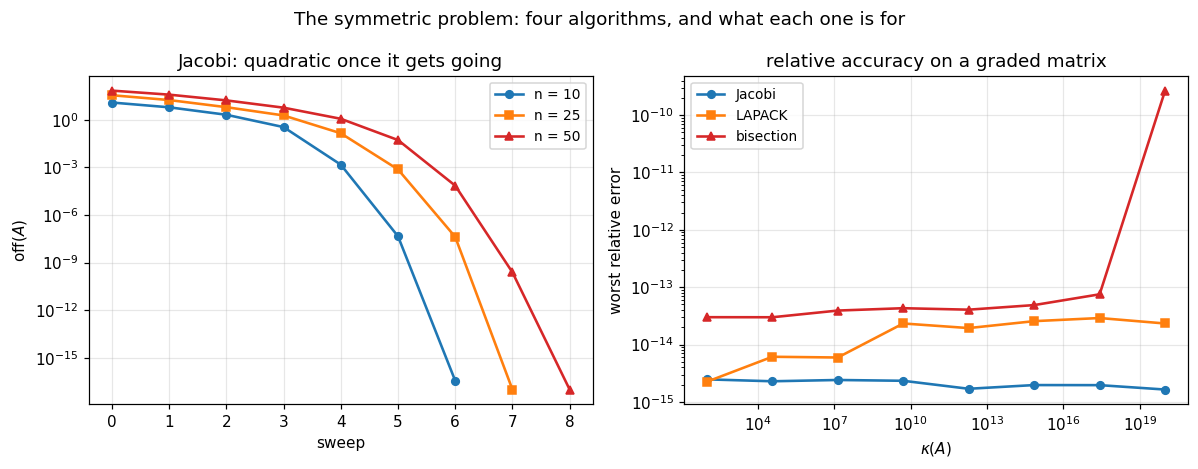

In [14]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

# left: Jacobi's off-diagonal norm collapsing, several sizes
for n_p, style in ((10, "C0o-"), (25, "C1s-"), (50, "C3^-")):
    A_p = np.random.default_rng(n_p).standard_normal((n_p, n_p))
    A_p = A_p + A_p.T
    trail = symeig.jacobi_eigen(A_p, compute_vectors=False).off_diagonal
    axL.semilogy(np.maximum(trail, 1e-17), style, lw=1.7, ms=5, label=f"n = {n_p}")
axL.set_xlabel("sweep")
axL.set_ylabel(r"$\mathrm{off}(A)$")
axL.set_title("Jacobi: quadratic once it gets going")
axL.legend(fontsize=9)

# right: relative accuracy against the condition number
spreads = np.geomspace(1e-1, 1e-10, 8)
curves = {"Jacobi": [], "LAPACK": [], "bisection": []}
kappas = []
for spread in spreads:
    g = symeig.graded_symmetric(10, float(spread), rng=np.random.default_rng(2))
    kappas.append(abs(g["exact"][-1] / g["exact"][0]))
    curves["Jacobi"].append(symeig.relative_accuracy(
        symeig.jacobi_eigen(g["A"], compute_vectors=False, max_sweeps=100).values,
        g["exact"]))
    curves["LAPACK"].append(symeig.relative_accuracy(
        np.sort(np.linalg.eigvalsh(g["A"])), g["exact"]))
    d_r, e_r = symeig.tridiagonalize(g["A"], compute_q=False)
    curves["bisection"].append(symeig.relative_accuracy(
        symeig.bisection_eigenvalues(d_r, e_r), g["exact"]))
for name, style in (("Jacobi", "C0o-"), ("LAPACK", "C1s-"), ("bisection", "C3^-")):
    axR.loglog(kappas, np.maximum(curves[name], 1e-17), style, lw=1.7, ms=5, label=name)
axR.set_xlabel(r"$\kappa(A)$")
axR.set_ylabel("worst relative error")
axR.set_title("relative accuracy on a graded matrix")
axR.legend(fontsize=9)

fig.suptitle("The symmetric problem: four algorithms, and what each one is for", fontsize=12)
fig.tight_layout()
plt.show()

**The right panel is section 7 in one image.** The Jacobi curve is flat across twenty orders of
magnitude of $\kappa$; the others are not.

---

## 10. Exercises

**Level 1, conceptual**

1.1 Symmetry buys four things. Name them, and say which one makes the tridiagonal reduction
possible.

1.2 A norm computed as $\sqrt{\|A\|^2 - \|\operatorname{diag}\|^2}$ passed every eigenvalue test
and failed the eigenvector test. Explain why the eigenvalues survived.

1.3 Bisection can find eigenvalue 37 of 1000 without the other 999. Why can neither Jacobi nor
the QR algorithm do that?

**Level 2, mathematical**

2.1 Show that a Jacobi rotation reduces $\operatorname{off}(A)^2$ by exactly $2a_{pq}^2$, and
hence that the method converges.

2.2 Prove the quadratic convergence of cyclic Jacobi once the off-diagonal norm is below the
smallest eigenvalue gap.

2.3 Prove that the Sturm count equals the number of eigenvalues below $x$, via Sylvester's law
of inertia and the $LDL^T$ factorization of $T - xI$.

2.4 Derive the secular equation from the rank-one update, and prove the interlacing that
brackets every root.

2.5 State the Demmel-Veselic theorem, identify the hypothesis on $B$ in $A = DBD$, and explain
why the theorem says nothing when $B$ is badly conditioned.

**Level 3, computational**

3.1 Implement the **tridiagonal QR algorithm** with the Wilkinson shift, using Givens rotations
so each step is $O(n)$. Compare against the dense version of lesson 37.

3.2 Implement **eigenvectors for divide and conquer**, including the Lowner formula for the
updated $\mathbf{z}$ that makes them orthogonal. Explain why the naive formula loses
orthogonality.

3.3 Implement **one-sided Jacobi**, which applies the rotations to the columns of $A$ rather
than to $A^TA$, and show it gives the SVD directly. This is lesson 42's method.

**Level 4, experimental**

4.1 Measure the cost of all four methods against $n$ and fit the exponents. Separate the cost
with and without eigenvectors.

4.2 Measure Jacobi's relative accuracy against $\kappa(B)$ rather than $\kappa(A)$, and confirm
that $\kappa(B)$ is the quantity the theorem names.

4.3 Measure how many sweeps Jacobi needs against $n$, for the cyclic and greedy orderings, and
fit the relationship.

**Level 5, advanced**

5.1 **Why Jacobi was abandoned and revived.** Trace the history: it lost to the QR algorithm on
speed in the 1960s and returned in the 1990s. Identify what changed, on both the theory side and
the hardware side.

5.2 **The MRRR algorithm.** LAPACK's newest symmetric solver computes eigenvectors in $O(n)$ each
with guaranteed orthogonality and no reorthogonalization. Describe the relatively robust
representations it rests on, and say what problem it solves that divide and conquer does not.

5.3 **Clustered eigenvalues.** Every method here degrades when eigenvalues cluster, but they
degrade differently. Construct a clustered spectrum, measure the eigenvector orthogonality from
each method, and explain the differences.

## 11. Key takeaways

- **Symmetry buys four things**: a real spectrum, orthogonal eigenvectors, condition number
  exactly 1 for every eigenvalue, and a **tridiagonal** rather than merely Hessenberg reduction.
- **Jacobi zeroes one pair at a time** and reduces $\operatorname{off}(A)^2$ by exactly
  $2a_{pq}^2$ each rotation, which is a convergence proof rather than an observation.
- **Its rotation uses the smaller root**, for two reasons: the angle stays below 45 degrees so
  the method converges rather than shuffling, and the formula avoids lesson 05's cancellation.
- **It converges quadratically.** Measured at $n = 40$: the last three sweeps go
  $3.5\times10^{-2}$, $2.7\times10^{-5}$, $4.4\times10^{-12}$.
- **A norm computed by subtraction returned exactly zero** while the off-diagonal was
  $1.4\times10^{-9}$, stopping Jacobi early. **The eigenvalues still looked perfect** because
  they are second order accurate in the eigenvector error; only $\|AV - VD\|$ caught it.
- **Tridiagonal form stores $n = 100$ in 199 numbers instead of 10000**, and makes every later
  step $O(n)$.
- **A Sturm count is one $O(n)$ sweep** and gives the number of eigenvalues below any point,
  from Sylvester's law of inertia.
- **So the index becomes a parameter.** Eigenvalue 13 of 20 costs the same as eigenvalue 0, and
  neither Jacobi nor the QR algorithm can offer that.
- **Divide and conquer glues two halves with a secular equation** whose every root is bracketed
  between consecutive poles by construction, so a bisection cannot fail.
- **A bare `z ** 2` broadcast against the wrong axis** and silently returned an $(n,n)$ array,
  giving a secular function that was nonzero at every true eigenvalue while looking perfectly
  reasonable. Caught by testing against an independently known answer.
- **Jacobi's relative accuracy is flat at $1.5\times10^{-15}$ across sixteen orders of magnitude
  of $\kappa(A)$**, which is the theorem and it is the real result.
- **It beats LAPACK by about 14 times, not by orders of magnitude.** The folklore overstates
  this. Bisection is the one that collapses, reaching $2.7\times10^{-10}$ at
  $\kappa = 10^{20}$.
- **And at low $\kappa$ Jacobi is slightly worse.** The advantage is specific to graded matrices
  with a wide spread.
- **The reference must not be the thing being tested.** An earlier version compared LAPACK
  against a longdouble round trip of LAPACK and scored it exactly zero. The fix was mpmath at 80
  digits.

## Where this goes next

**Lesson 39** returns to Krylov methods for matrices far too large to tridiagonalize, where
Lanczos plays the role the reduction plays here.

**Lesson 40** handles $A\mathbf{x} = \lambda B\mathbf{x}$, which reduces to this lesson's
problem by a Cholesky factorization when $B$ is positive definite, and needs QZ when it is not.

**Lesson 41** builds the SVD, which is the symmetric eigenvalue problem of $A^TA$, and **lesson
42** computes it without ever forming $A^TA$, using the one-sided Jacobi of exercise 3.3 and the
bidiagonal analogue of section 4.